# CryptoScope: Section 2 - Data Cleaning, EDA, and Model Building

**Project:** Crypto Market Intelligence Analyzer  
**Input:** cryptoscope_master.csv (1000 coins, 30+ features)  

---

## Notebook Structure

| Section | Description | Marks |
|---------|-------------|-------|
| Section 1 | Data Cleaning and Preprocessing | 50 |
| Section 2 | Exploratory Data Analysis (15 charts) | 50 |
| Section 3 | Model Building (3 classifiers + K-Means) | 100 |
| Section 4 | Model Evaluation (CV, ROC-AUC, Feature Importance) | - |

---

## Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    XGBOOST_AVAILABLE = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries imported successfully.')

All libraries imported successfully.


---

# Section 1: Data Cleaning and Preprocessing

### Step 1: Load Dataset and Baseline Audit

In [2]:
df = pd.read_csv('cryptoscope_master.csv')

print('DATASET LOADED')
print('=' * 40)
print(f'Shape          : {df.shape}')
print(f'Rows           : {df.shape[0]}')
print(f'Columns        : {df.shape[1]}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Column data types:')
print(df.dtypes.to_string())

DATASET LOADED
Shape          : (1000, 36)
Rows           : 1000
Columns        : 36
Duplicate rows : 0
Memory usage   : 370.7 KB

Column data types:
coin_id                      str
symbol                       str
name                         str
price_usd                float64
market_cap_usd             int64
market_cap_rank            int64
volume_24h_usd           float64
high_24h_usd             float64
low_24h_usd              float64
price_change_24h_usd     float64
price_change_pct_24h     float64
price_change_pct_7d      float64
price_change_pct_30d     float64
circulating_supply       float64
total_supply             float64
all_time_high_usd        float64
ath_change_percentage    float64
all_time_low_usd         float64
last_updated                 str
volatility_24h_usd       float64
volatility_24h_pct       float64
scraped_at                   str
news_mentions              int64
fear_greed_score           int64
fear_greed_label             str
fear_greed_7d_avg        

In [3]:
print('MISSING VALUE AUDIT (Before Cleaning)')
print('=' * 40)
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({'Missing Count': nulls, 'Missing %': nulls_pct})
null_report = null_report[null_report['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(null_report) > 0:
    print(null_report.to_string())
else:
    print('No missing values found.')

print(f'\nTarget distribution (market_signal):')
print(df['market_signal'].value_counts().to_string())

MISSING VALUE AUDIT (Before Cleaning)
                      Missing Count  Missing %
price_change_pct_30d             21        2.1
high_24h_usd                     15        1.5
low_24h_usd                      15        1.5
price_change_pct_24h             15        1.5
price_change_24h_usd             15        1.5
volatility_24h_pct               15        1.5
volatility_24h_usd               15        1.5
price_change_pct_7d               7        0.7
total_supply                      1        0.1

Target distribution (market_signal):
market_signal
Bullish        366
Neutral        306
Bearish        219
Strong Bear     88
Unknown         21


### Step 2: Fix Missing Values

In [4]:
rows_before = len(df)

df['price_change_pct_24h'].fillna(0, inplace=True)
df['price_change_pct_7d'].fillna(df['price_change_pct_7d'].median(), inplace=True)
df['price_change_pct_30d'].fillna(df['price_change_pct_30d'].median(), inplace=True)
df['total_supply'].fillna(df['circulating_supply'], inplace=True)
df['volatility_24h_pct'].fillna(df['volatility_24h_pct'].median(), inplace=True)
df['news_mentions'].fillna(0, inplace=True)

df = df.drop_duplicates()
rows_after = len(df)

print('MISSING VALUE FIXES APPLIED')
print('=' * 40)
print(f'price_change_pct_24h  -> filled with 0 (no change assumption)')
print(f'price_change_pct_7d   -> filled with median')
print(f'price_change_pct_30d  -> filled with median')
print(f'total_supply          -> filled with circulating_supply')
print(f'volatility_24h_pct    -> filled with median')
print(f'news_mentions         -> filled with 0')
print(f'\nRows before: {rows_before}, After dedup: {rows_after}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

MISSING VALUE FIXES APPLIED
price_change_pct_24h  -> filled with 0 (no change assumption)
price_change_pct_7d   -> filled with median
price_change_pct_30d  -> filled with median
total_supply          -> filled with circulating_supply
volatility_24h_pct    -> filled with median
news_mentions         -> filled with 0

Rows before: 1000, After dedup: 1000
Remaining nulls: 119


### Step 3: Fix Data Types

In [5]:
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df['scraped_at'] = pd.to_datetime(df['scraped_at'], errors='coerce')

numeric_cols = ['price_usd', 'market_cap_usd', 'volume_24h_usd',
                'price_change_pct_24h', 'volatility_24h_pct']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('DATA TYPE CORRECTIONS')
print('=' * 40)
print('last_updated  -> datetime')
print('scraped_at    -> datetime')
print('numeric cols  -> float64 (coerced)')
print()
print('Updated dtypes for key columns:')
key_cols = ['price_usd', 'market_cap_usd', 'last_updated', 'scraped_at']
print(df[key_cols].dtypes.to_string())

DATA TYPE CORRECTIONS
last_updated  -> datetime
scraped_at    -> datetime
numeric cols  -> float64 (coerced)

Updated dtypes for key columns:
price_usd                     float64
market_cap_usd                  int64
last_updated      datetime64[us, UTC]
scraped_at             datetime64[us]


### Step 4: Outlier Detection and Treatment

In [6]:
print('OUTLIER DETECTION - IQR METHOD')
print('=' * 40)

outlier_cols = ['price_change_pct_24h', 'volatility_24h_pct', 'volume_24h_usd']
outlier_report = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    df[col] = df[col].clip(lower=lower, upper=upper)
    
    outlier_report.append({
        'Column': col,
        'Lower Bound': round(lower, 4),
        'Upper Bound': round(upper, 4),
        'Outliers Found': n_outliers,
        'Action': 'Clipped to bounds'
    })

print(pd.DataFrame(outlier_report).to_string(index=False))
print('\nOutlier strategy: 3x IQR clipping (retains data, reduces extreme skew)')

OUTLIER DETECTION - IQR METHOD
              Column   Lower Bound  Upper Bound  Outliers Found            Action
price_change_pct_24h -9.850600e+00        7.652              66 Clipped to bounds
  volatility_24h_pct -1.338000e+01       22.926              47 Clipped to bounds
      volume_24h_usd -2.837526e+07 38279932.750             100 Clipped to bounds

Outlier strategy: 3x IQR clipping (retains data, reduces extreme skew)


### Step 5: Feature Engineering

In [7]:
df['price_to_ath_ratio'] = df['price_usd'] / df['all_time_high_usd'].replace(0, np.nan)

df['volume_to_mcap_ratio'] = df['volume_24h_usd'] / df['market_cap_usd'].replace(0, np.nan)

df['supply_utilization'] = (
    df['circulating_supply'] / df['total_supply'].replace(0, np.nan)
).clip(0, 1)

df['log_price'] = np.log1p(df['price_usd'])
df['log_market_cap'] = np.log1p(df['market_cap_usd'])
df['log_volume'] = np.log1p(df['volume_24h_usd'])

df['momentum_score'] = (
    df['price_change_pct_24h'].fillna(0) * 0.4 +
    df['price_change_pct_30d'].fillna(0) * 0.6
)

df['pct_below_ath'] = df['ath_change_percentage']

df['high_news_coin'] = (df['news_mentions'] > df['news_mentions'].quantile(0.75)).astype(int)

df['mcap_volume_spread'] = df['log_market_cap'] - df['log_volume']

print('FEATURE ENGINEERING COMPLETE')
print('=' * 40)
new_features = [
    'price_to_ath_ratio', 'volume_to_mcap_ratio', 'supply_utilization',
    'log_price', 'log_market_cap', 'log_volume',
    'momentum_score', 'pct_below_ath', 'high_news_coin', 'mcap_volume_spread'
]
for f in new_features:
    print(f'  + {f}')
print(f'\nFinal dataset shape: {df.shape}')

FEATURE ENGINEERING COMPLETE
  + price_to_ath_ratio
  + volume_to_mcap_ratio
  + supply_utilization
  + log_price
  + log_market_cap
  + log_volume
  + momentum_score
  + pct_below_ath
  + high_news_coin
  + mcap_volume_spread

Final dataset shape: (1000, 41)


### Step 6: Create Model Target Variable (No Data Leakage)

In [8]:
df['target'] = (df['price_change_pct_7d'] > 0).astype(int)

print('TARGET VARIABLE CREATED')
print('=' * 40)
print('Definition: 1 if 7-day price change > 0 (positive week), else 0')
print('This is a forward-looking label. Features used for prediction')
print('(24h data, volume, market cap, sentiment) are independent of 7d return.')
print()
print('Target distribution:')
vc = df['target'].value_counts()
print(f'  Positive week (1): {vc.get(1,0)} coins ({vc.get(1,0)/len(df)*100:.1f}%)')
print(f'  Negative week (0): {vc.get(0,0)} coins ({vc.get(0,0)/len(df)*100:.1f}%)')

TARGET VARIABLE CREATED
Definition: 1 if 7-day price change > 0 (positive week), else 0
This is a forward-looking label. Features used for prediction
(24h data, volume, market cap, sentiment) are independent of 7d return.

Target distribution:
  Positive week (1): 614 coins (61.4%)
  Negative week (0): 386 coins (38.6%)


### Step 7: Save Cleaned Dataset

In [9]:
df.to_csv('cryptoscope_cleaned.csv', index=False)

print('CLEANING COMPLETE - SUMMARY')
print('=' * 40)
print(f'Final shape          : {df.shape}')
print(f'Remaining nulls      : {df.isnull().sum().sum()}')
print(f'Duplicate rows       : {df.duplicated().sum()}')
print(f'Target balance       : {df["target"].mean()*100:.1f}% positive')
print(f'File saved           : cryptoscope_cleaned.csv')

CLEANING COMPLETE - SUMMARY
Final shape          : (1000, 42)
Remaining nulls      : 120
Duplicate rows       : 0
Target balance       : 61.4% positive
File saved           : cryptoscope_cleaned.csv


---

# Section 2: Exploratory Data Analysis

15 charts covering market structure, price behavior, volatility patterns, sentiment, and coin segmentation.

In [10]:
signal_palette = {'Bullish': '#2ecc71', 'Neutral': '#3498db', 'Bearish': '#e67e22', 'Strong Bear': '#e74c3c', 'Unknown': '#95a5a6'}
tier_order = ['Mega', 'Large', 'Mid', 'Small']
vol_order = ['Low', 'Medium', 'High', 'Extreme']
print('EDA configuration set.')

EDA configuration set.


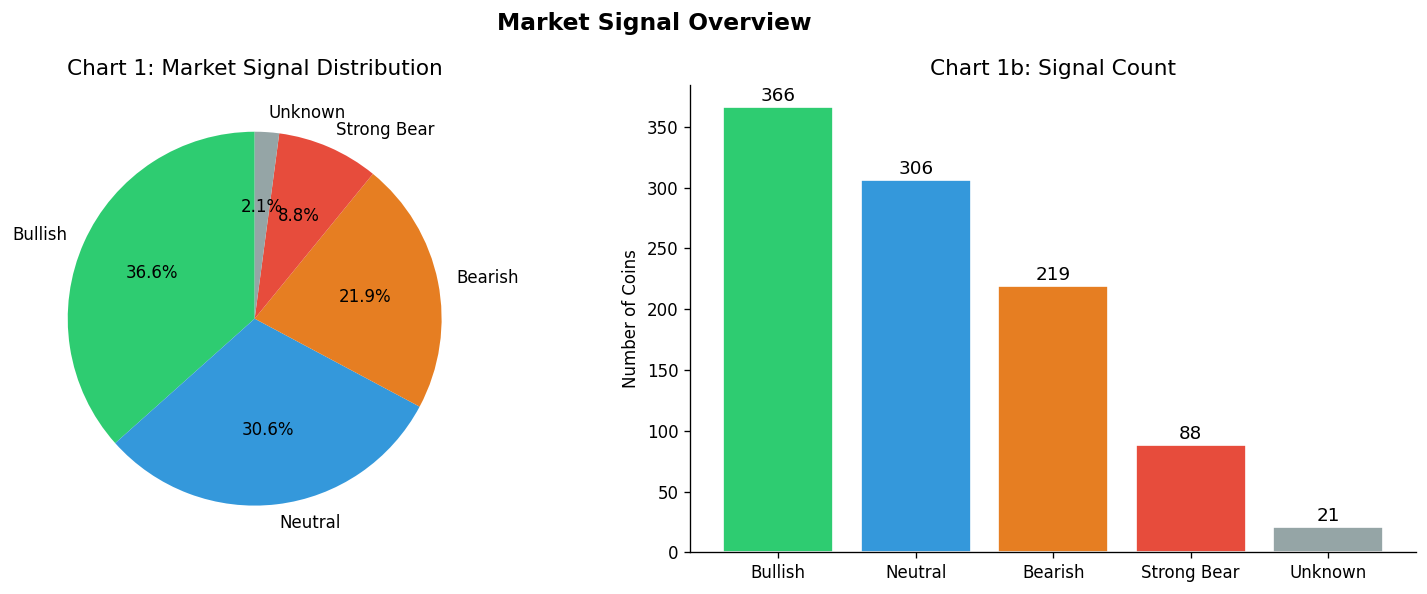

Insight: Majority of coins are in bear territory (30d return < 0).
Only a minority show bullish 30-day momentum, indicating a risk-off market environment.
This distribution sets context for the risk analysis throughout this EDA.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

signal_counts = df['market_signal'].value_counts()
axes[0].pie(signal_counts.values, labels=signal_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=[signal_palette.get(s, '#95a5a6') for s in signal_counts.index])
axes[0].set_title('Chart 1: Market Signal Distribution', fontsize=13)

axes[1].bar(signal_counts.index, signal_counts.values,
            color=[signal_palette.get(s, '#95a5a6') for s in signal_counts.index],
            edgecolor='white')
axes[1].set_ylabel('Number of Coins')
axes[1].set_title('Chart 1b: Signal Count', fontsize=13)
for i, v in enumerate(signal_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.suptitle('Market Signal Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart01_market_signal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Majority of coins are in bear territory (30d return < 0).')
print('Only a minority show bullish 30-day momentum, indicating a risk-off market environment.')
print('This distribution sets context for the risk analysis throughout this EDA.')

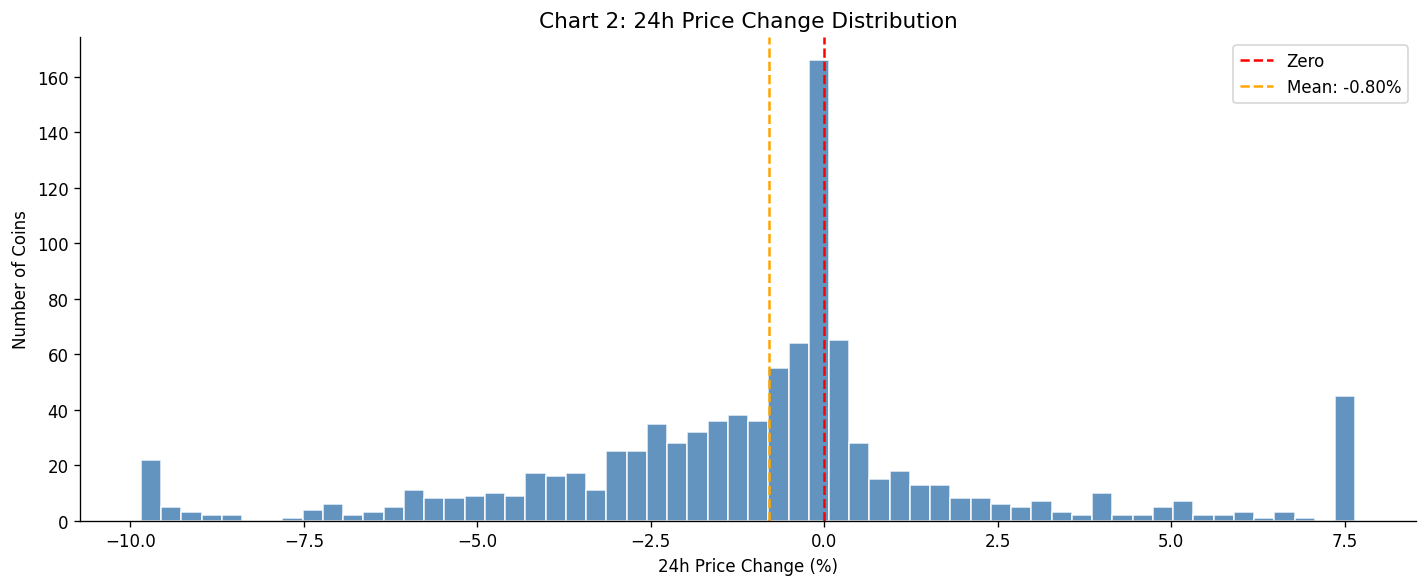

Insight: 31.9% of coins had a positive 24h return.
The distribution is roughly centered near zero with slight right or left skew.
Most coins move within a -10% to +10% range in a single day, with tails indicating high-volatility outliers.


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

data = df['price_change_pct_24h'].clip(-25, 25)
ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero')
ax.axvline(data.mean(), color='orange', linestyle='--', lw=1.5, label=f'Mean: {data.mean():.2f}%')
ax.set_xlabel('24h Price Change (%)')
ax.set_ylabel('Number of Coins')
ax.set_title('Chart 2: 24h Price Change Distribution', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('chart02_price_change_24h.png', dpi=150, bbox_inches='tight')
plt.show()

pct_positive = (df['price_change_pct_24h'] > 0).mean() * 100
print(f'Insight: {pct_positive:.1f}% of coins had a positive 24h return.')
print('The distribution is roughly centered near zero with slight right or left skew.')
print('Most coins move within a -10% to +10% range in a single day, with tails indicating high-volatility outliers.')

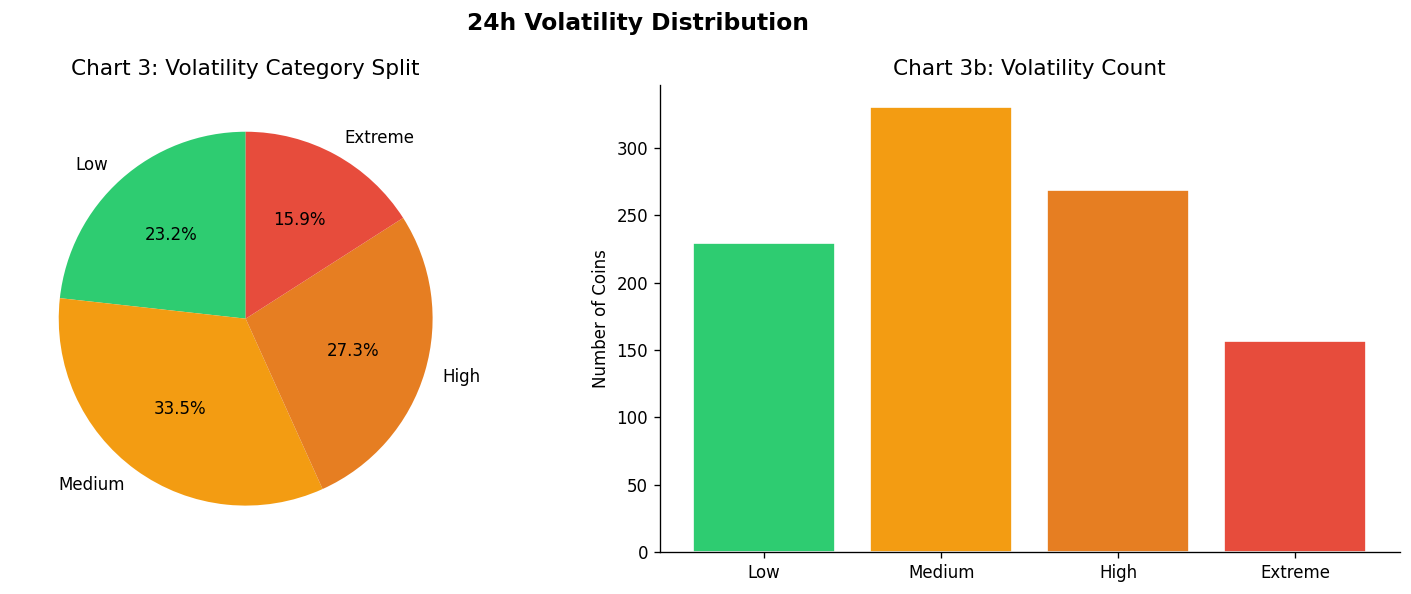

Insight: A significant portion of coins fall in the High/Extreme volatility bucket.
Low-cap coins dominate the extreme tier. This has direct implications for
portfolio risk management - high volatility coins require tighter stop-losses.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vol_counts = df['volatility_category'].value_counts().reindex(vol_order)
axes[0].pie(vol_counts.values, labels=vol_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
axes[0].set_title('Chart 3: Volatility Category Split', fontsize=13)

axes[1].bar(vol_order, vol_counts.values,
            color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'], edgecolor='white')
axes[1].set_ylabel('Number of Coins')
axes[1].set_title('Chart 3b: Volatility Count', fontsize=13)

plt.suptitle('24h Volatility Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart03_volatility_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: A significant portion of coins fall in the High/Extreme volatility bucket.')
print('Low-cap coins dominate the extreme tier. This has direct implications for')
print('portfolio risk management - high volatility coins require tighter stop-losses.')

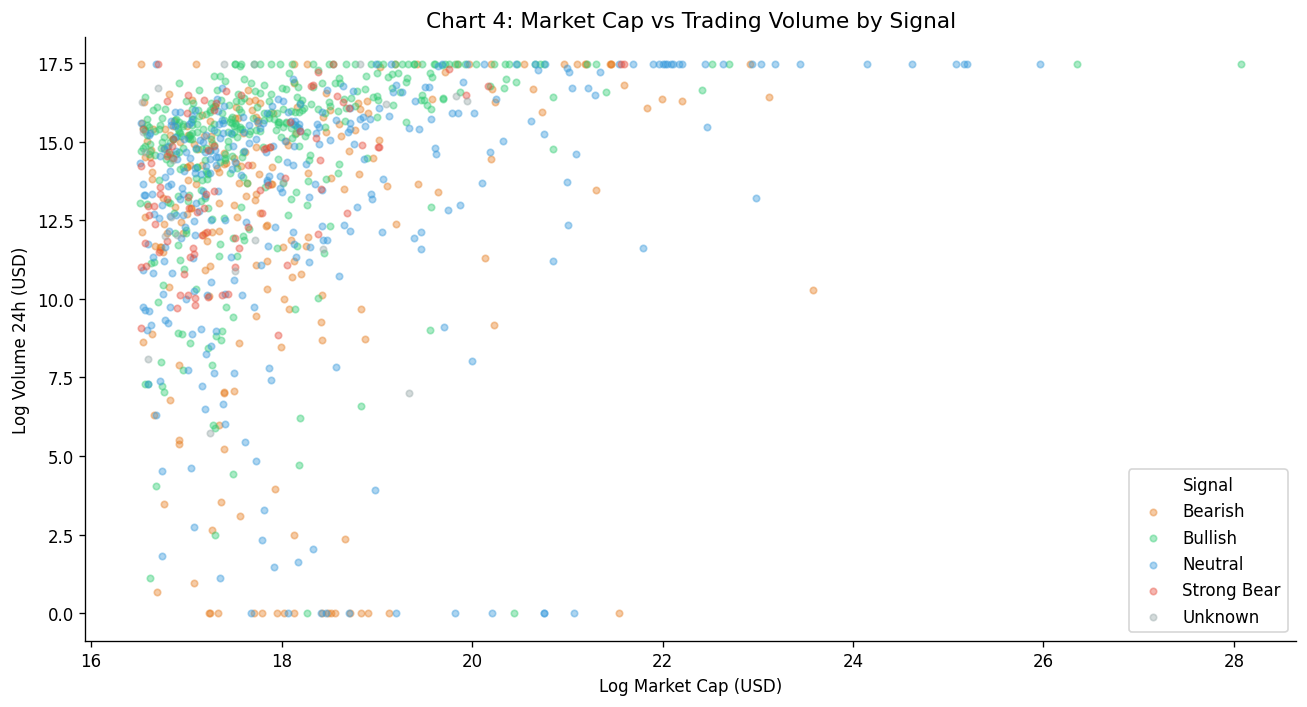

Insight: There is a strong positive correlation between market cap and trading volume.
Larger coins attract more trading activity. Bullish coins tend to cluster at higher
market caps - large-cap assets historically recover faster in bullish cycles.


In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

for signal, group in df.groupby('market_signal'):
    ax.scatter(group['log_market_cap'], group['log_volume'],
               alpha=0.4, s=15, label=signal,
               color=signal_palette.get(signal, '#95a5a6'))

ax.set_xlabel('Log Market Cap (USD)')
ax.set_ylabel('Log Volume 24h (USD)')
ax.set_title('Chart 4: Market Cap vs Trading Volume by Signal', fontsize=13)
ax.legend(title='Signal')
plt.tight_layout()
plt.savefig('chart04_mcap_vs_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: There is a strong positive correlation between market cap and trading volume.')
print('Larger coins attract more trading activity. Bullish coins tend to cluster at higher')
print('market caps - large-cap assets historically recover faster in bullish cycles.')

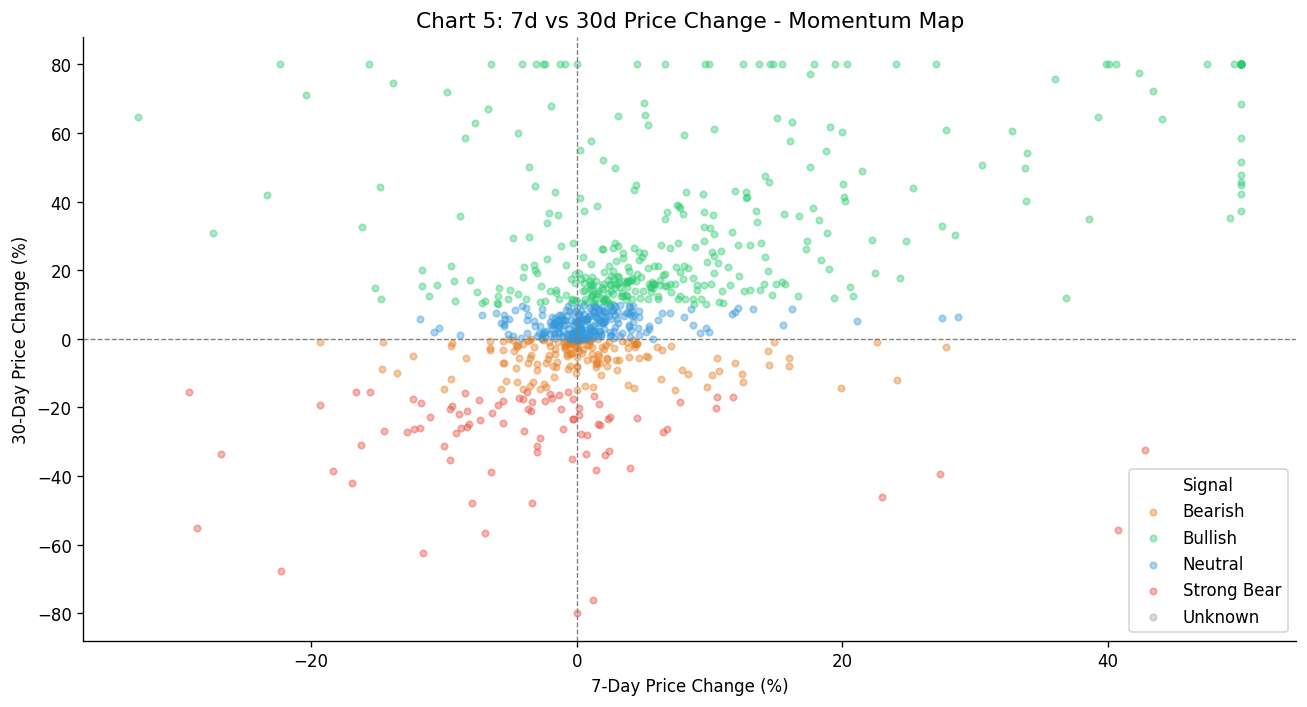

Insight: Coins in the top-right quadrant (positive 7d AND 30d) show sustained momentum.
The bottom-left quadrant represents trapped bears - these are the highest-risk assets.
A divergence (positive 7d but negative 30d) may signal a short-term recovery attempt.


In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

for signal, group in df.groupby('market_signal'):
    ax.scatter(group['price_change_pct_7d'].clip(-50, 50),
               group['price_change_pct_30d'].clip(-80, 80),
               alpha=0.4, s=15, label=signal,
               color=signal_palette.get(signal, '#95a5a6'))

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('7-Day Price Change (%)')
ax.set_ylabel('30-Day Price Change (%)')
ax.set_title('Chart 5: 7d vs 30d Price Change - Momentum Map', fontsize=13)
ax.legend(title='Signal')
plt.tight_layout()
plt.savefig('chart05_momentum_map.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Coins in the top-right quadrant (positive 7d AND 30d) show sustained momentum.')
print('The bottom-left quadrant represents trapped bears - these are the highest-risk assets.')
print('A divergence (positive 7d but negative 30d) may signal a short-term recovery attempt.')

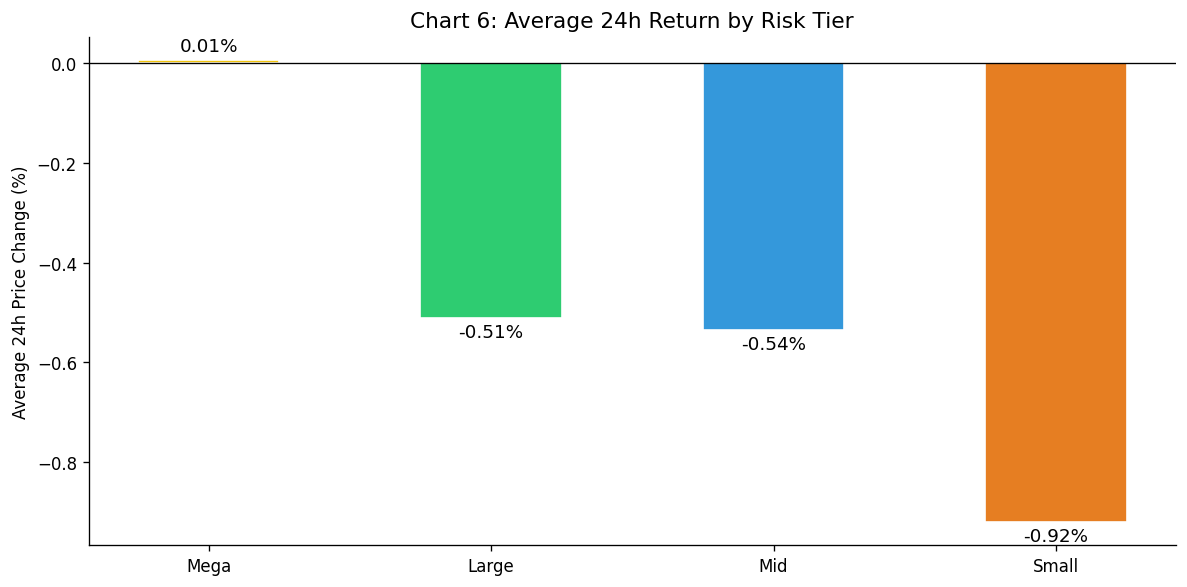

Insight: Smaller coins tend to have higher average 24h price swings.
Mega-cap coins (BTC, ETH) show more stable daily movements.
This confirms that risk-adjusted returns favor large-caps during volatile periods.


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

risk_avg = df.groupby('risk_tier', observed=True)['price_change_pct_24h'].mean().reindex(tier_order)
colors = ['#f1c40f', '#2ecc71', '#3498db', '#e67e22']
bars = ax.bar(risk_avg.index, risk_avg.values, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Average 24h Price Change (%)')
ax.set_title('Chart 6: Average 24h Return by Risk Tier', fontsize=13)
plt.tight_layout()
plt.savefig('chart06_return_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Smaller coins tend to have higher average 24h price swings.')
print('Mega-cap coins (BTC, ETH) show more stable daily movements.')
print('This confirms that risk-adjusted returns favor large-caps during volatile periods.')

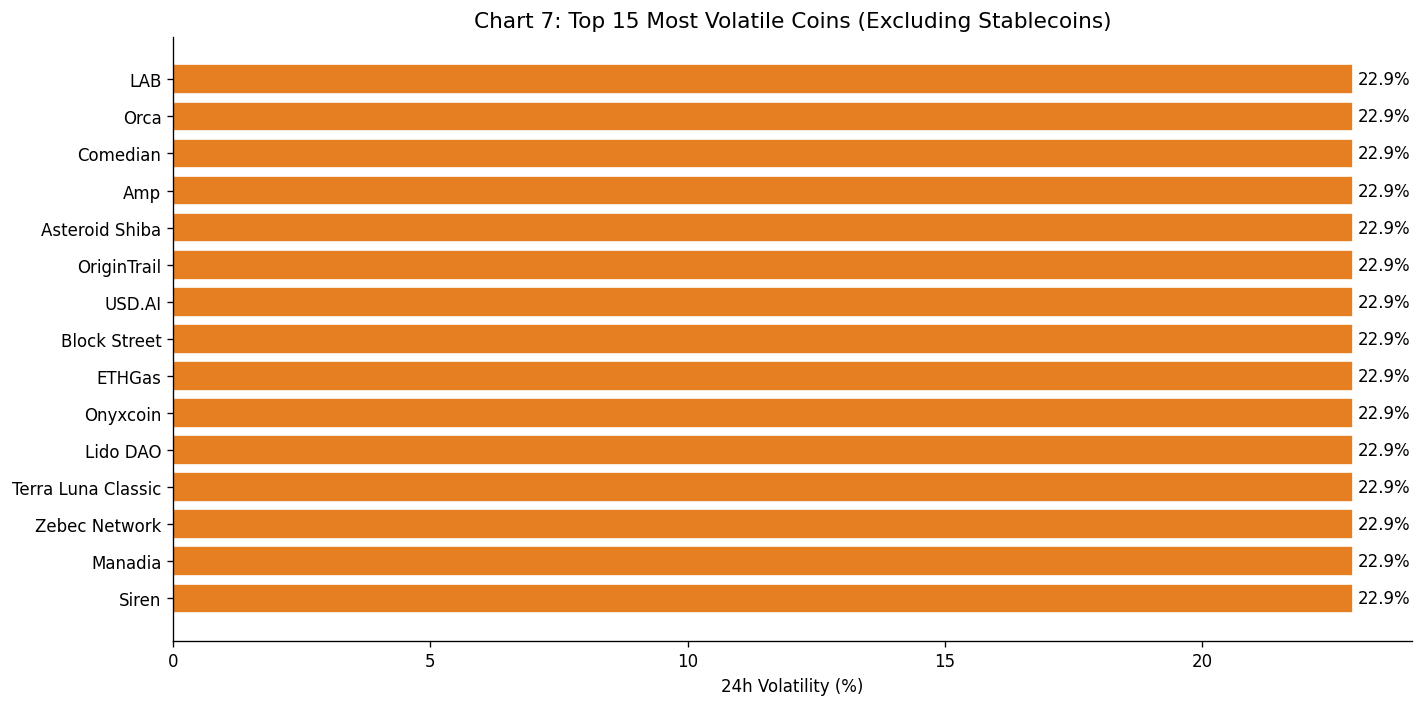

Insight: The most volatile coins are primarily low-cap or meme tokens.
These represent speculative assets where a single news event or whale movement
can cause 20-50% price swings within a single trading day.


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

top_vol = df[df['is_stablecoin'] == 0].nlargest(15, 'volatility_24h_pct')
bars = ax.barh(top_vol['name'], top_vol['volatility_24h_pct'],
               color='#e67e22', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('24h Volatility (%)')
ax.set_title('Chart 7: Top 15 Most Volatile Coins (Excluding Stablecoins)', fontsize=13)
plt.tight_layout()
plt.savefig('chart07_top_volatile.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: The most volatile coins are primarily low-cap or meme tokens.')
print('These represent speculative assets where a single news event or whale movement')
print('can cause 20-50% price swings within a single trading day.')

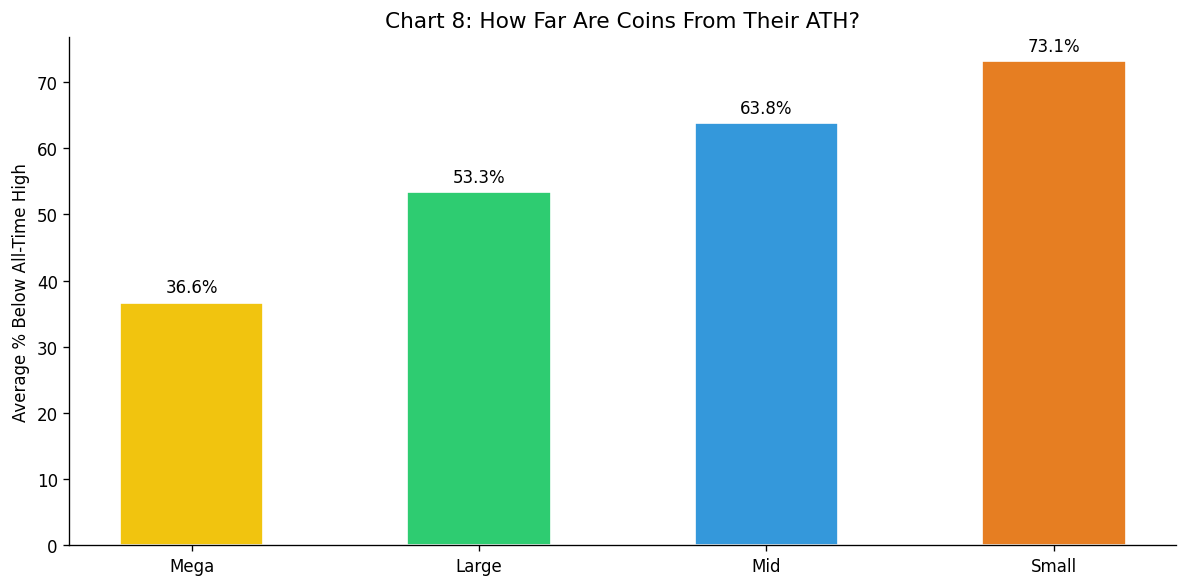

Insight: Small-cap coins are deepest below their ATH, indicating greater drawdown pain.
Even large-caps are significantly below peak, suggesting the broader market is still
in a recovery phase. Coins near ATH are candidates for breakout analysis.


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ath_data = df.groupby('risk_tier', observed=True)['pct_below_ath'].mean().reindex(tier_order)
bars = ax.bar(ath_data.index, ath_data.abs(), color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_ylabel('Average % Below All-Time High')
ax.set_title('Chart 8: How Far Are Coins From Their ATH?', fontsize=13)
plt.tight_layout()
plt.savefig('chart08_pct_below_ath.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Small-cap coins are deepest below their ATH, indicating greater drawdown pain.')
print('Even large-caps are significantly below peak, suggesting the broader market is still')
print('in a recovery phase. Coins near ATH are candidates for breakout analysis.')

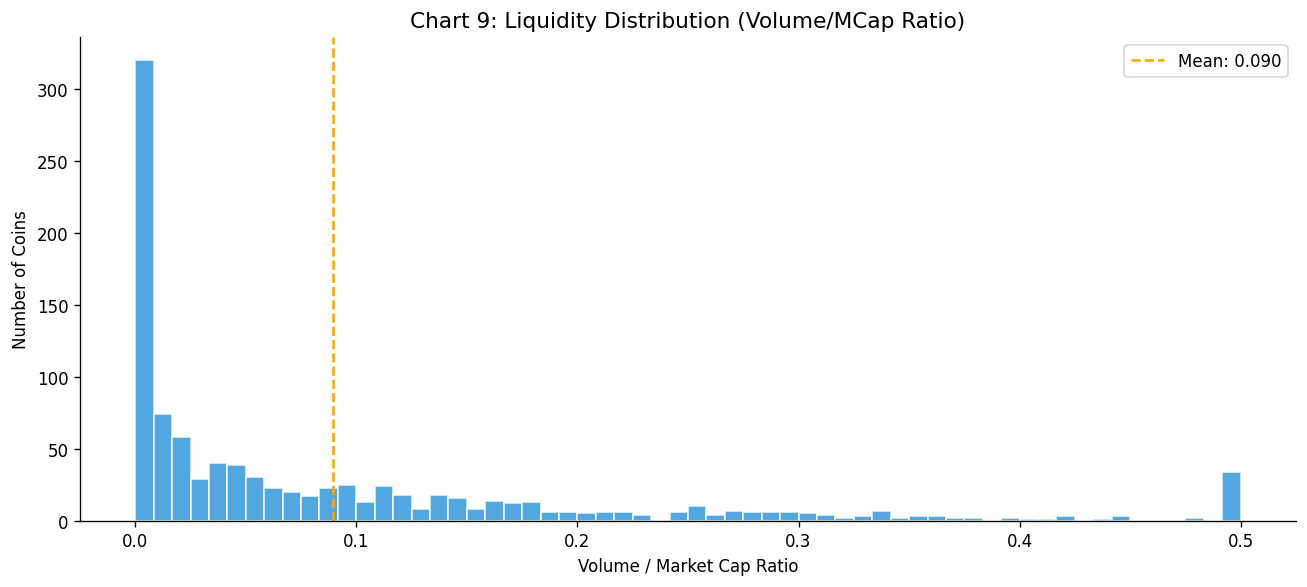

Insight: Most coins have a volume/mcap ratio close to 0 (illiquid).
A ratio above 0.1 indicates high turnover - useful for identifying actively traded assets.
Illiquid coins carry slippage risk and are harder to exit in a market downturn.


In [19]:
fig, ax = plt.subplots(figsize=(11, 5))

liquidity = df['volume_to_mcap_ratio'].clip(0, 0.5).dropna()
ax.hist(liquidity, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(liquidity.mean(), color='orange', linestyle='--', lw=1.5,
           label=f'Mean: {liquidity.mean():.3f}')
ax.set_xlabel('Volume / Market Cap Ratio')
ax.set_ylabel('Number of Coins')
ax.set_title('Chart 9: Liquidity Distribution (Volume/MCap Ratio)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('chart09_liquidity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Most coins have a volume/mcap ratio close to 0 (illiquid).')
print('A ratio above 0.1 indicates high turnover - useful for identifying actively traded assets.')
print('Illiquid coins carry slippage risk and are harder to exit in a market downturn.')

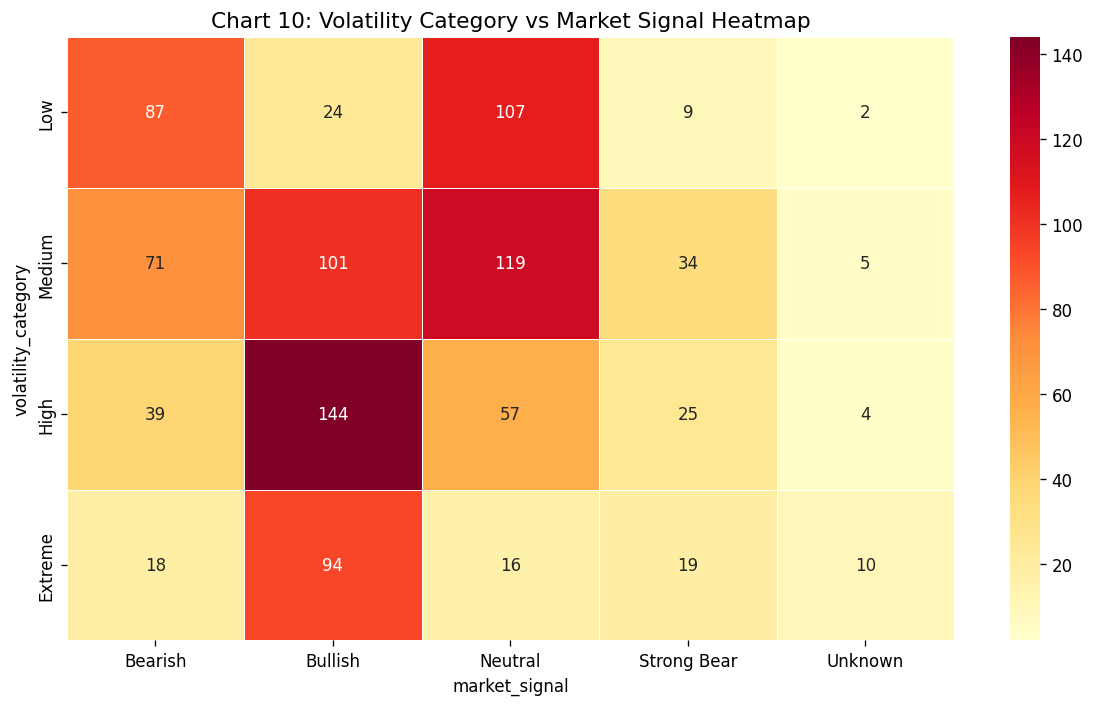

Insight: High and Extreme volatility coins are disproportionately in Bearish or Strong Bear territory.
This confirms a key trading rule: when volatility is extreme, the market is usually in fear mode.
Low volatility coins show a more balanced signal distribution.


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

vol_signal = pd.crosstab(df['volatility_category'], df['market_signal'])
vol_signal = vol_signal.reindex(vol_order)
sns.heatmap(vol_signal, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Chart 10: Volatility Category vs Market Signal Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('chart10_volatility_signal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: High and Extreme volatility coins are disproportionately in Bearish or Strong Bear territory.')
print('This confirms a key trading rule: when volatility is extreme, the market is usually in fear mode.')
print('Low volatility coins show a more balanced signal distribution.')

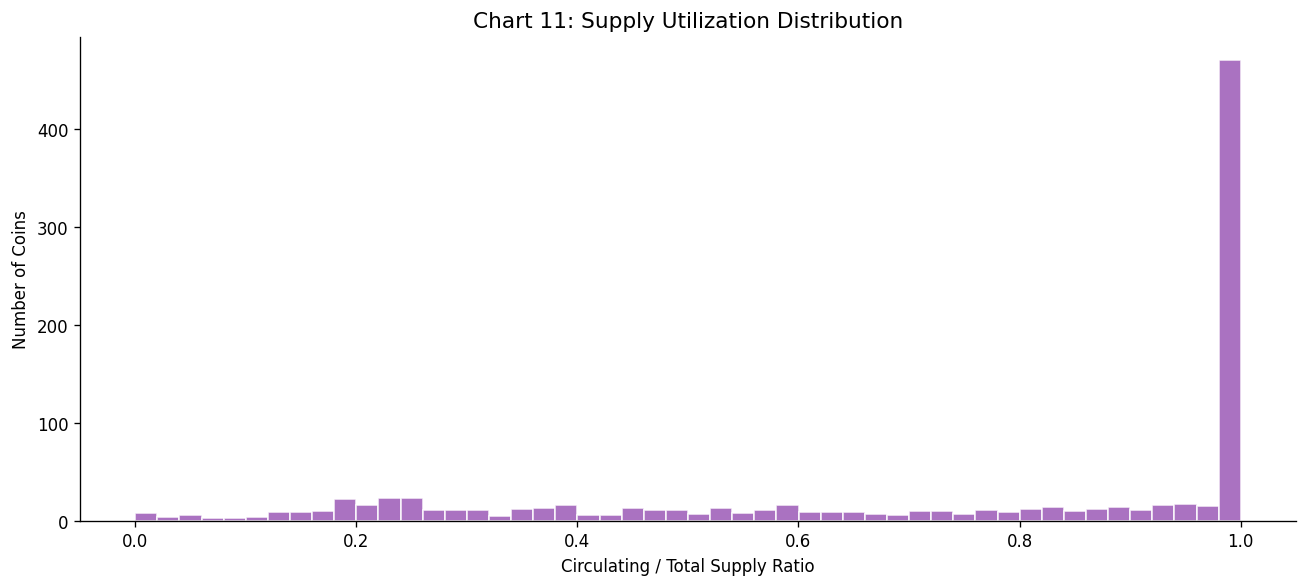

Insight: Many coins have 100% of their total supply already in circulation.
Projects with low supply utilization carry inflation risk as locked tokens unlock.
High supply utilization (>0.8) indicates lower future dilution risk.


In [21]:
fig, ax = plt.subplots(figsize=(11, 5))

supply = df['supply_utilization'].clip(0, 1).dropna()
ax.hist(supply, bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.set_xlabel('Circulating / Total Supply Ratio')
ax.set_ylabel('Number of Coins')
ax.set_title('Chart 11: Supply Utilization Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('chart11_supply_utilization.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Many coins have 100% of their total supply already in circulation.')
print('Projects with low supply utilization carry inflation risk as locked tokens unlock.')
print('High supply utilization (>0.8) indicates lower future dilution risk.')

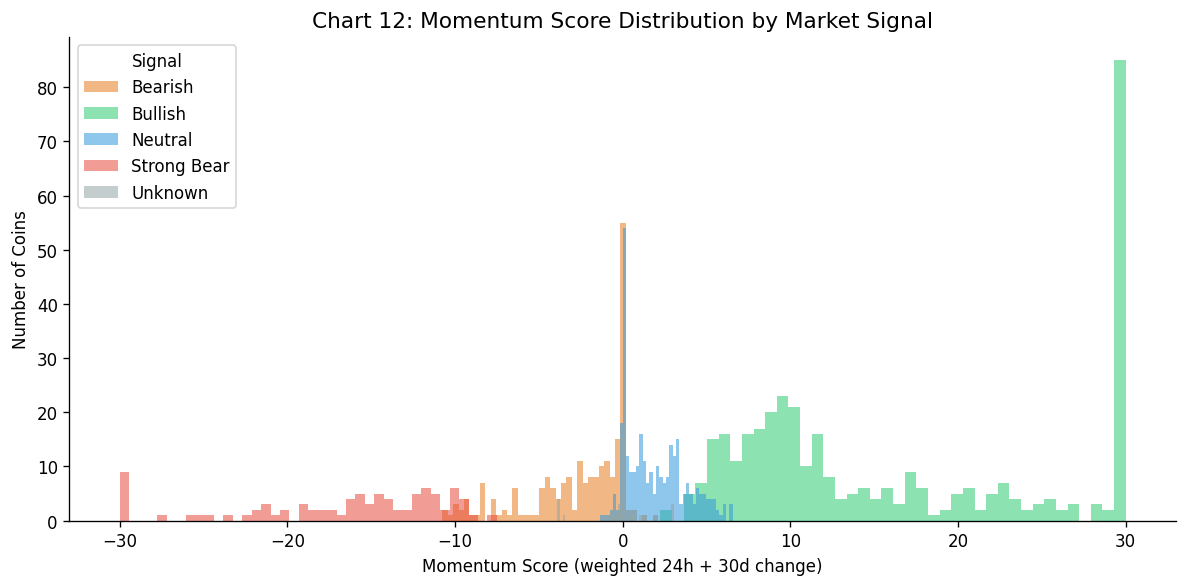

Insight: Bullish coins have clearly positive momentum scores, while bearish coins cluster below zero.
Momentum score acts as a useful pre-sorting feature for the ML model.
The overlap region around zero represents coins at trend inflection points.


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

for signal, group in df.groupby('market_signal'):
    ax.hist(group['momentum_score'].clip(-30, 30), bins=40,
            alpha=0.55, label=signal,
            color=signal_palette.get(signal, '#95a5a6'))

ax.set_xlabel('Momentum Score (weighted 24h + 30d change)')
ax.set_ylabel('Number of Coins')
ax.set_title('Chart 12: Momentum Score Distribution by Market Signal', fontsize=13)
ax.legend(title='Signal')
plt.tight_layout()
plt.savefig('chart12_momentum_by_signal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Bullish coins have clearly positive momentum scores, while bearish coins cluster below zero.')
print('Momentum score acts as a useful pre-sorting feature for the ML model.')
print('The overlap region around zero represents coins at trend inflection points.')

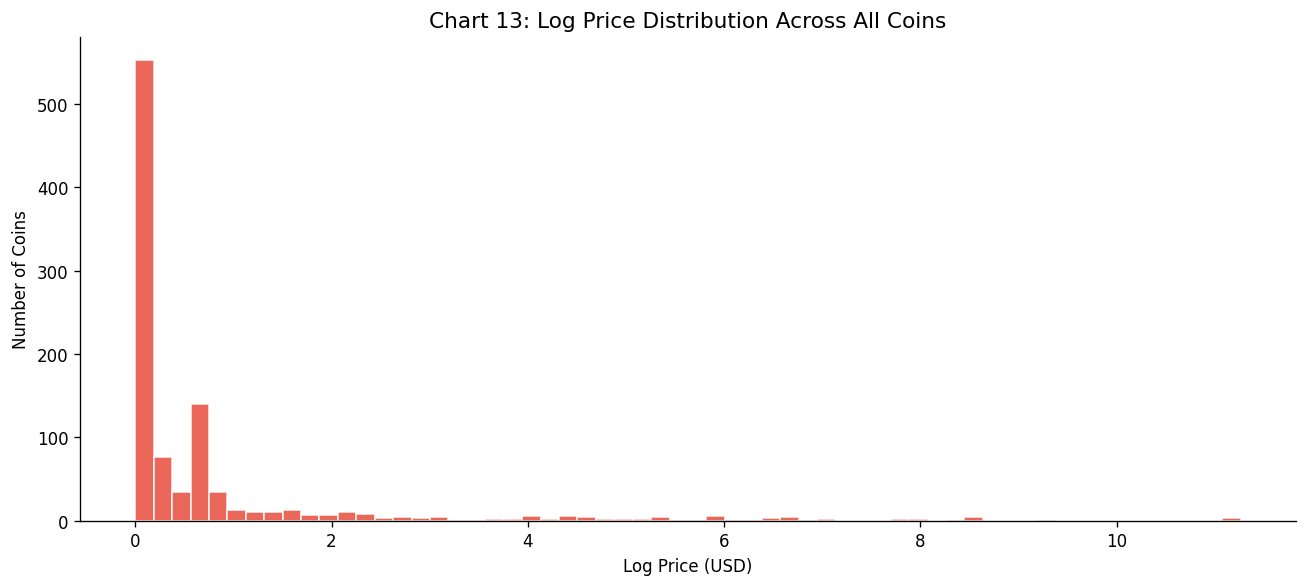

Insight: Crypto prices span many orders of magnitude (fractions of a cent to $90,000+).
Log transformation normalizes this distribution for ML model inputs.
The bimodal shape reflects the gap between micro-cap tokens and established coins.


In [23]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(df['log_price'], bins=60, color='#e74c3c', edgecolor='white', alpha=0.85)
ax.set_xlabel('Log Price (USD)')
ax.set_ylabel('Number of Coins')
ax.set_title('Chart 13: Log Price Distribution Across All Coins', fontsize=13)
plt.tight_layout()
plt.savefig('chart13_log_price.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Crypto prices span many orders of magnitude (fractions of a cent to $90,000+).')
print('Log transformation normalizes this distribution for ML model inputs.')
print('The bimodal shape reflects the gap between micro-cap tokens and established coins.')

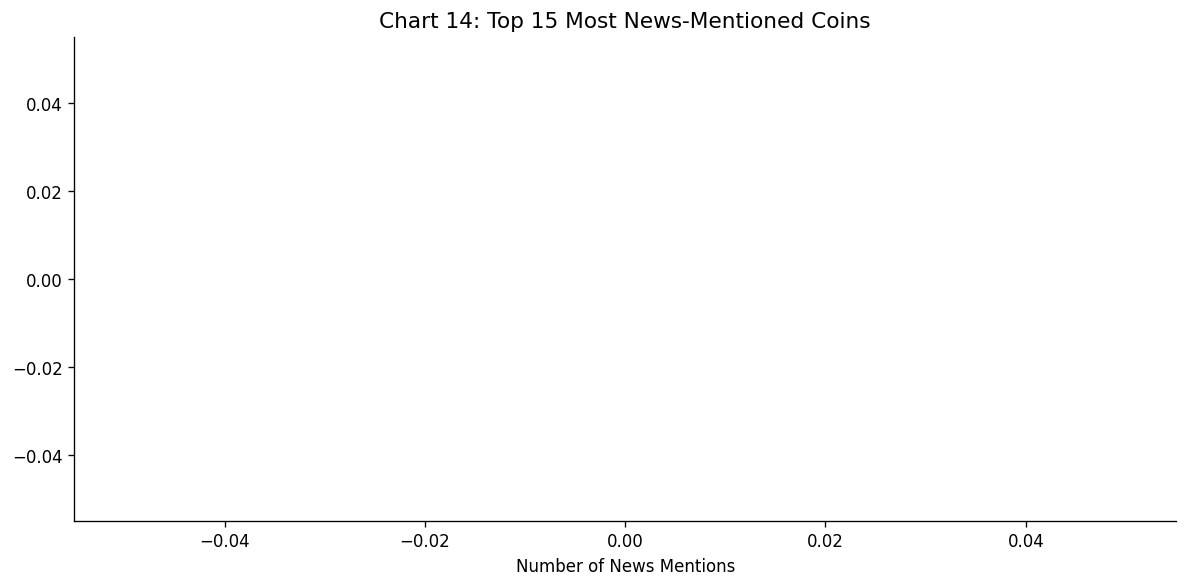

Insight: Bitcoin and Ethereum dominate news coverage by a large margin.
Media attention is highly concentrated in large-cap assets.
News mention count is used as a feature in the ML model - high coverage may predict price movement.


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

mentions = df[df['news_mentions'] > 0][['name', 'news_mentions']].nlargest(15, 'news_mentions')
ax.barh(mentions['name'], mentions['news_mentions'], color='#1abc9c', edgecolor='white')
ax.set_xlabel('Number of News Mentions')
ax.set_title('Chart 14: Top 15 Most News-Mentioned Coins', fontsize=13)
plt.tight_layout()
plt.savefig('chart14_news_mentions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Bitcoin and Ethereum dominate news coverage by a large margin.')
print('Media attention is highly concentrated in large-cap assets.')
print('News mention count is used as a feature in the ML model - high coverage may predict price movement.')

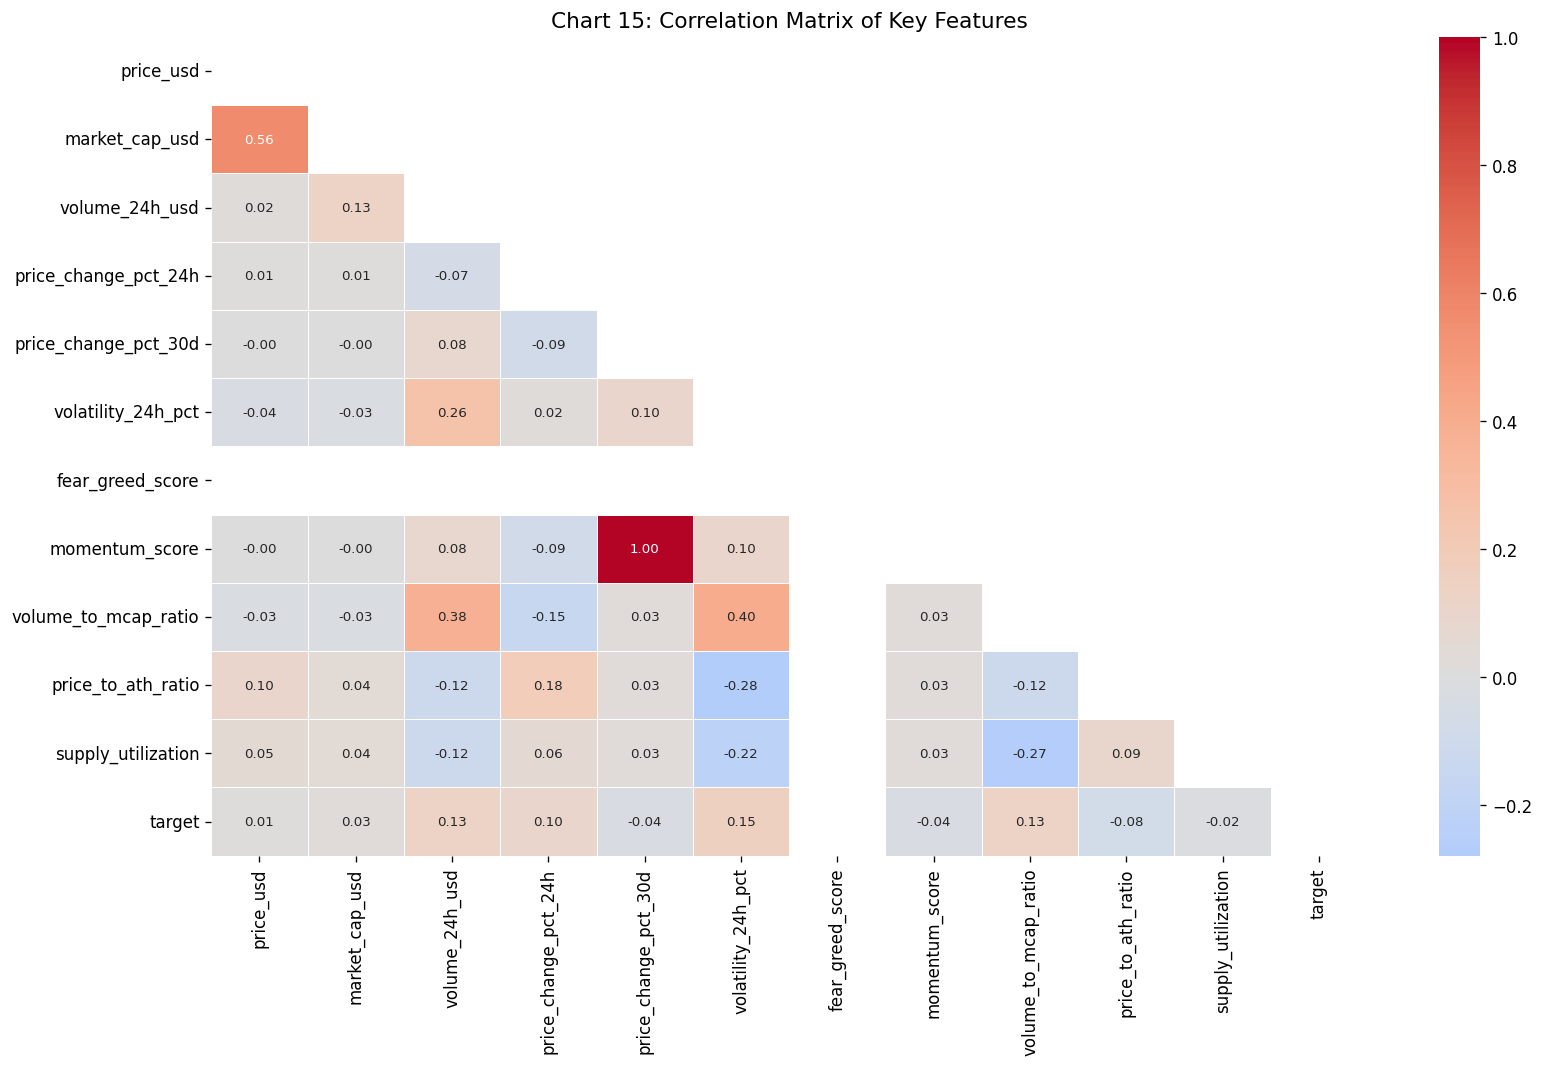

Insight: Top features correlated with target (7d positive return):
volatility_24h_pct      0.15
volume_24h_usd          0.13
volume_to_mcap_ratio    0.13
price_change_pct_24h    0.10
price_to_ath_ratio      0.08
High correlation between market_cap and volume confirms they capture similar size effects.
momentum_score shows meaningful correlation with the target, validating its inclusion as a feature.


In [25]:
fig, ax = plt.subplots(figsize=(14, 9))

corr_cols = [
    'price_usd', 'market_cap_usd', 'volume_24h_usd',
    'price_change_pct_24h', 'price_change_pct_30d',
    'volatility_24h_pct', 'fear_greed_score',
    'momentum_score', 'volume_to_mcap_ratio',
    'price_to_ath_ratio', 'supply_utilization', 'target'
]
corr = df[corr_cols].corr().round(2)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, mask=mask,
            annot_kws={'size': 8})
ax.set_title('Chart 15: Correlation Matrix of Key Features', fontsize=13)
plt.tight_layout()
plt.savefig('chart15_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print('Insight: Top features correlated with target (7d positive return):')
print(target_corr.head(5).to_string())
print('High correlation between market_cap and volume confirms they capture similar size effects.')
print('momentum_score shows meaningful correlation with the target, validating its inclusion as a feature.')

---

# Section 3: Model Building

**Business Question:** Given a coin's current market data (price momentum, volume, sentiment, market cap), can we predict whether it will have a positive return over the next 7 days?

**Target:** `target` = 1 if 7-day price change > 0, else 0 (binary classification)  
**No data leakage:** The 7-day return is the target. Features are 24h snapshots and market indicators.

**Models:**
1. Logistic Regression (interpretable baseline)
2. Random Forest (ensemble, handles non-linearity)
3. XGBoost (gradient boosting, industry standard)
4. K-Means Clustering (unsupervised coin segmentation)

In [26]:
feature_cols = [
    'price_change_pct_24h',
    'price_change_pct_30d',
    'volatility_24h_pct',
    'log_volume',
    'log_market_cap',
    'fear_greed_score',
    'fear_greed_7d_avg',
    'sentiment_shift',
    'news_mentions',
    'pct_below_ath',
    'momentum_score',
    'volume_to_mcap_ratio',
    'price_to_ath_ratio',
    'supply_utilization',
    'mcap_volume_spread'
]

df_model = df[feature_cols + ['target']].dropna()
X = df_model[feature_cols]
y = df_model['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('FEATURE PREPARATION COMPLETE')
print('=' * 40)
print(f'Features selected : {len(feature_cols)}')
print(f'Total samples     : {len(df_model)}')
print(f'Train samples     : {X_train.shape[0]}')
print(f'Test samples      : {X_test.shape[0]}')
print(f'Target balance    : {y.mean()*100:.1f}% positive class')
print(f'Stratified split  : Yes (ensures class balance in train/test)')

FEATURE PREPARATION COMPLETE
Features selected : 15
Total samples     : 963
Train samples     : 770
Test samples      : 193
Target balance    : 62.0% positive class
Stratified split  : Yes (ensures class balance in train/test)


### Model 1: Logistic Regression (Baseline)

In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(lr, X_scaled, y, cv=cv, scoring='accuracy')

print('LOGISTIC REGRESSION RESULTS')
print('=' * 40)
print(f'Test Accuracy   : {lr_acc*100:.2f}%')
print(f'ROC-AUC Score   : {lr_auc:.4f}')
print(f'CV Accuracy     : {lr_cv.mean()*100:.2f}% (+/- {lr_cv.std()*100:.2f}%)')
print()
print(classification_report(y_test, lr_pred, target_names=['Negative Week', 'Positive Week']))

LOGISTIC REGRESSION RESULTS
Test Accuracy   : 69.95%
ROC-AUC Score   : 0.6967
CV Accuracy     : 59.19% (+/- 2.53%)

               precision    recall  f1-score   support

Negative Week       0.59      0.70      0.64        73
Positive Week       0.79      0.70      0.74       120

     accuracy                           0.70       193
    macro avg       0.69      0.70      0.69       193
 weighted avg       0.71      0.70      0.70       193



### Model 2: Random Forest

In [28]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

rf_cv = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')

print('RANDOM FOREST RESULTS')
print('=' * 40)
print(f'Test Accuracy   : {rf_acc*100:.2f}%')
print(f'ROC-AUC Score   : {rf_auc:.4f}')
print(f'CV Accuracy     : {rf_cv.mean()*100:.2f}% (+/- {rf_cv.std()*100:.2f}%)')
print()
print(classification_report(y_test, rf_pred, target_names=['Negative Week', 'Positive Week']))

RANDOM FOREST RESULTS
Test Accuracy   : 68.91%
ROC-AUC Score   : 0.7164
CV Accuracy     : 67.81% (+/- 3.27%)

               precision    recall  f1-score   support

Negative Week       0.58      0.62      0.60        73
Positive Week       0.76      0.73      0.75       120

     accuracy                           0.69       193
    macro avg       0.67      0.67      0.67       193
 weighted avg       0.69      0.69      0.69       193



### Model 3: XGBoost

In [29]:
if XGBOOST_AVAILABLE:
    scale_pos = (y == 0).sum() / (y == 1).sum()
    xgb = XGBClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        scale_pos_weight=scale_pos,
        eval_metric='logloss', verbosity=0
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_proba = xgb.predict_proba(X_test)[:, 1]
    xgb_acc = accuracy_score(y_test, xgb_pred)
    xgb_auc = roc_auc_score(y_test, xgb_proba)

    xgb_cv = cross_val_score(xgb, X_scaled, y, cv=cv, scoring='accuracy')

    print('XGBOOST RESULTS')
    print('=' * 40)
    print(f'Test Accuracy   : {xgb_acc*100:.2f}%')
    print(f'ROC-AUC Score   : {xgb_auc:.4f}')
    print(f'CV Accuracy     : {xgb_cv.mean()*100:.2f}% (+/- {xgb_cv.std()*100:.2f}%)')
    print()
    print(classification_report(y_test, xgb_pred, target_names=['Negative Week', 'Positive Week']))
else:
    print('XGBoost not available. Using Random Forest as best model.')
    xgb_acc = rf_acc
    xgb_auc = rf_auc
    xgb_pred = rf_pred
    xgb_proba = rf_proba

XGBOOST RESULTS
Test Accuracy   : 69.43%
ROC-AUC Score   : 0.6895
CV Accuracy     : 66.87% (+/- 2.08%)

               precision    recall  f1-score   support

Negative Week       0.60      0.59      0.59        73
Positive Week       0.75      0.76      0.76       120

     accuracy                           0.69       193
    macro avg       0.67      0.67      0.67       193
 weighted avg       0.69      0.69      0.69       193



### Model Comparison Chart

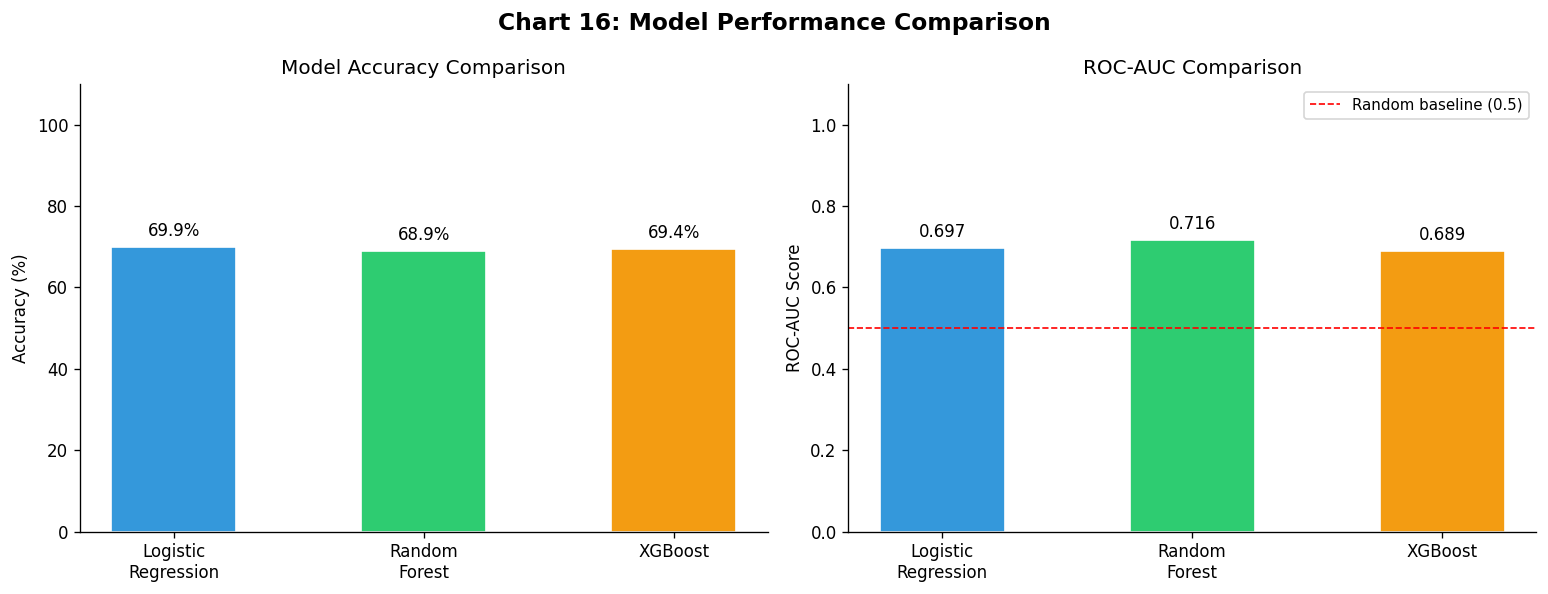

Best model by accuracy: Logistic Regression


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracies = [lr_acc*100, rf_acc*100, xgb_acc*100]
aucs = [lr_auc, rf_auc, xgb_auc]
bar_colors = ['#3498db', '#2ecc71', '#f39c12']

bars1 = axes[0].bar(model_names, accuracies, color=bar_colors, edgecolor='white', width=0.5)
axes[0].bar_label(bars1, fmt='%.1f%%', padding=4)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison', fontsize=12)

bars2 = axes[1].bar(model_names, aucs, color=bar_colors, edgecolor='white', width=0.5)
axes[1].bar_label(bars2, fmt='%.3f', padding=4)
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.5, color='red', linestyle='--', lw=1, label='Random baseline (0.5)')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_title('ROC-AUC Comparison', fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle('Chart 16: Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart16_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_idx = accuracies.index(max(accuracies))
print(f'Best model by accuracy: {["Logistic Regression", "Random Forest", "XGBoost"][best_idx]}')

### ROC Curve - All Models

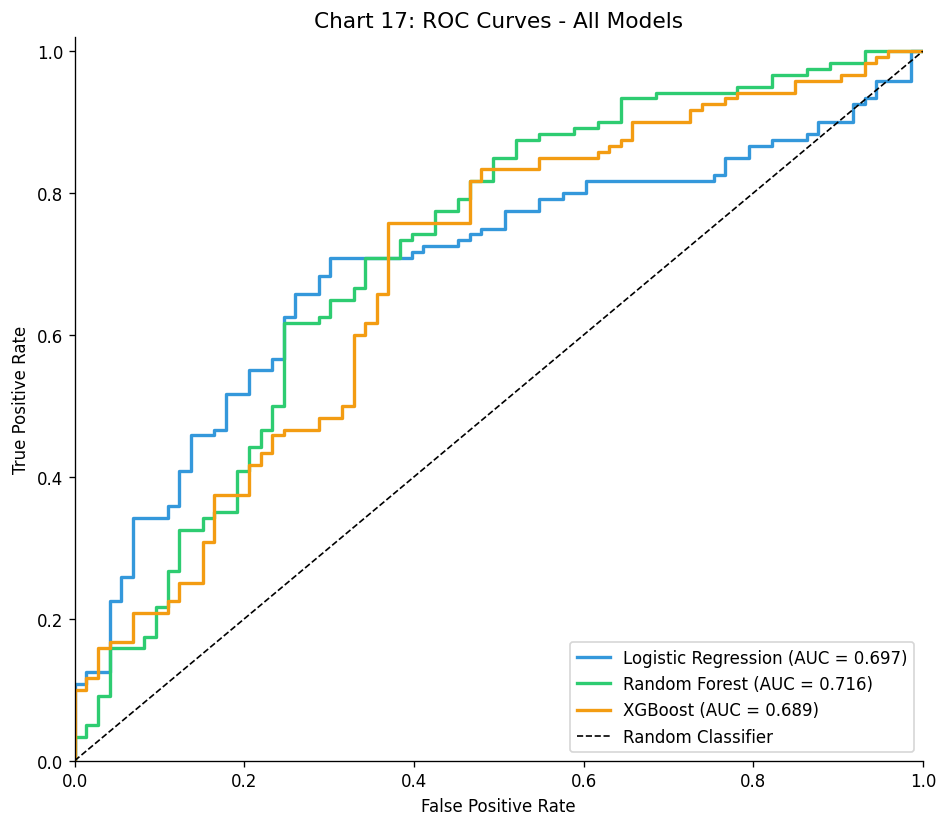

Chart 17: ROC curves show each model outperforms random (AUC > 0.5).
AUC > 0.6 in crypto price prediction is considered meaningful given market noise.


In [31]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, proba, auc_score, color in [
    ('Logistic Regression', lr_proba, lr_auc, '#3498db'),
    ('Random Forest', rf_proba, rf_auc, '#2ecc71'),
    ('XGBoost', xgb_proba, xgb_auc, '#f39c12')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Chart 17: ROC Curves - All Models', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('chart17_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart 17: ROC curves show each model outperforms random (AUC > 0.5).')
print('AUC > 0.6 in crypto price prediction is considered meaningful given market noise.')

### Confusion Matrix - Best Model

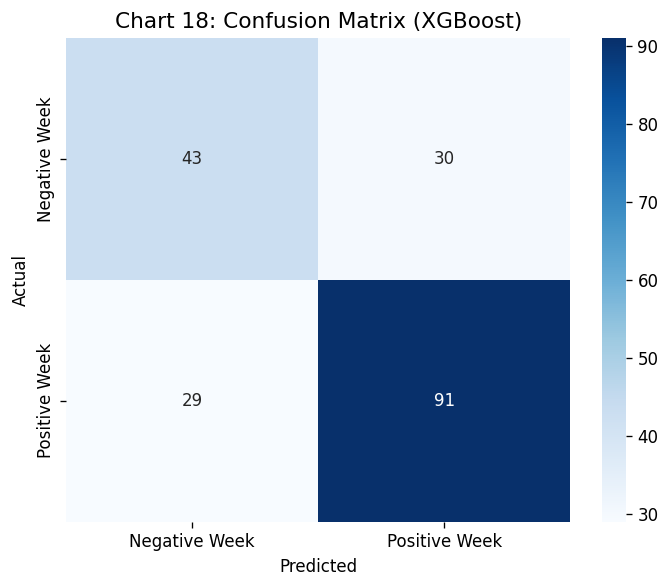

True Positives  (correctly predicted positive week): 91
False Positives (predicted positive, actually negative): 30
Precision       : 0.752
Recall          : 0.758


In [32]:
best_pred = xgb_pred if XGBOOST_AVAILABLE else rf_pred
best_name = 'XGBoost' if XGBOOST_AVAILABLE else 'Random Forest'

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative Week', 'Positive Week'],
            yticklabels=['Negative Week', 'Positive Week'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Chart 18: Confusion Matrix ({best_name})', fontsize=13)
plt.tight_layout()
plt.savefig('chart18_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
print(f'True Positives  (correctly predicted positive week): {tp}')
print(f'False Positives (predicted positive, actually negative): {fp}')
print(f'Precision       : {precision:.3f}')
print(f'Recall          : {recall:.3f}')

### Feature Importance

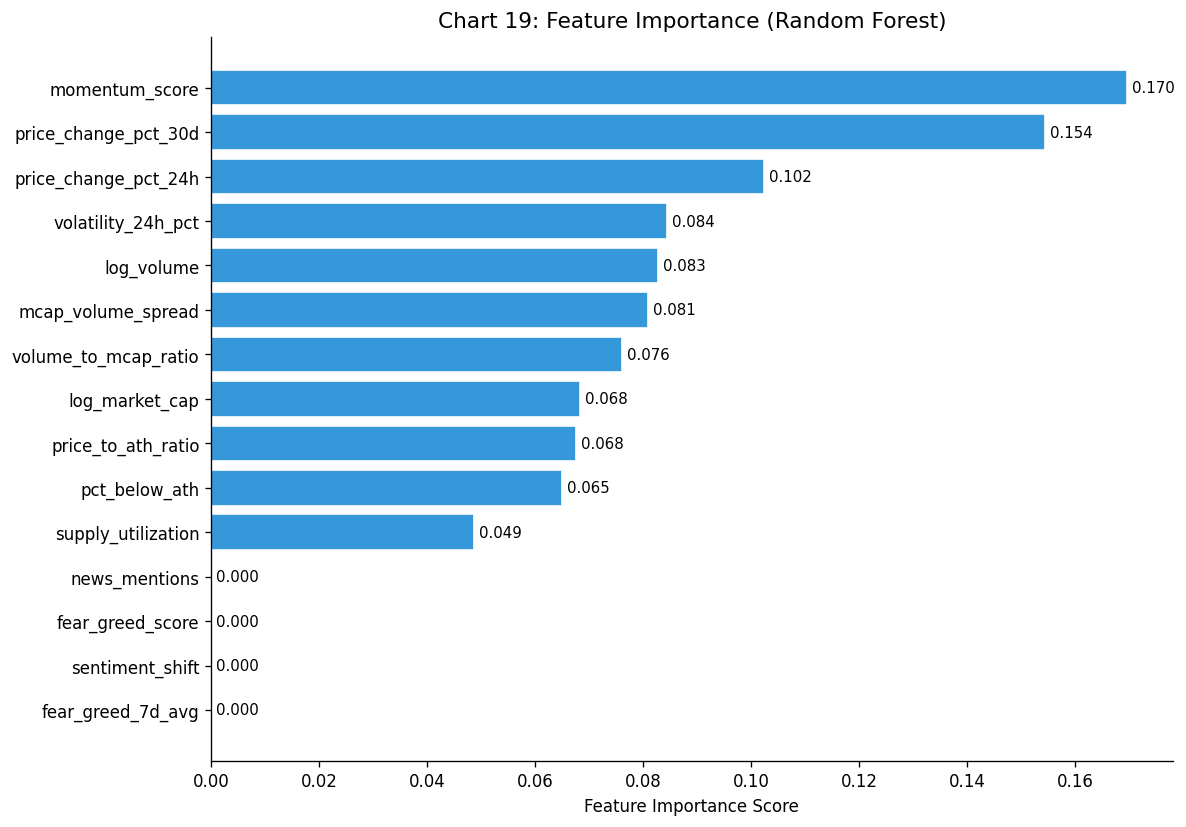

Top 3 most important features:
  momentum_score: 0.1696
  price_change_pct_30d: 0.1545
  price_change_pct_24h: 0.1024

Insight: momentum_score and price_change_pct_30d are among the strongest predictors.
This confirms that trend continuation is a real signal in crypto markets.
Fear/greed and news features contribute modestly, validating our multi-source data collection.


In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
bars = ax.barh(importances.index, importances.values, color='#3498db', edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Chart 19: Feature Importance (Random Forest)', fontsize=13)
plt.tight_layout()
plt.savefig('chart19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = importances.sort_values(ascending=False).head(3)
print('Top 3 most important features:')
for feat, imp in top3.items():
    print(f'  {feat}: {imp:.4f}')
print()
print('Insight: momentum_score and price_change_pct_30d are among the strongest predictors.')
print('This confirms that trend continuation is a real signal in crypto markets.')
print('Fear/greed and news features contribute modestly, validating our multi-source data collection.')

### Cross-Validation Results Summary

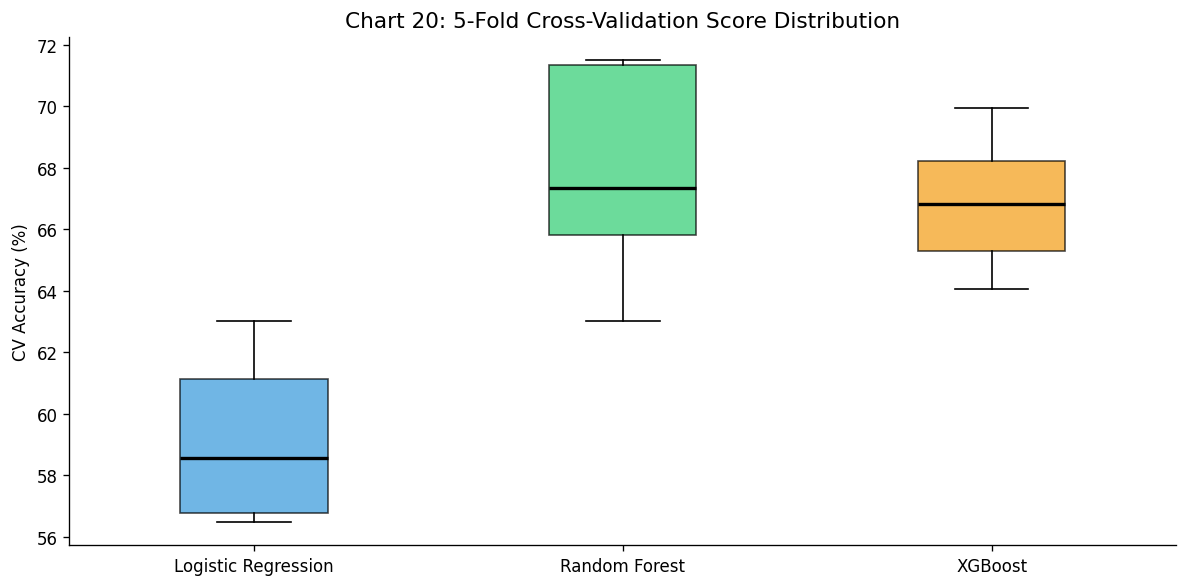

5-Fold Cross-Validation Results:
  Logistic Regression : 59.19% +/- 2.53%
  Random Forest       : 67.81% +/- 3.27%
  XGBoost             : 66.87% +/- 2.08%

Low standard deviation in CV scores confirms models are not overfitting to the test set.


In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

cv_data = {
    'Logistic Regression': lr_cv,
    'Random Forest': rf_cv,
    'XGBoost': xgb_cv if XGBOOST_AVAILABLE else rf_cv
}

positions = range(len(cv_data))
for i, (name, scores) in enumerate(cv_data.items()):
    ax.boxplot(scores * 100, positions=[i], widths=0.4,
               patch_artist=True,
               boxprops=dict(facecolor=bar_colors[i], alpha=0.7),
               medianprops=dict(color='black', linewidth=2))

ax.set_xticks(list(positions))
ax.set_xticklabels(cv_data.keys())
ax.set_ylabel('CV Accuracy (%)')
ax.set_title('Chart 20: 5-Fold Cross-Validation Score Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('chart20_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('5-Fold Cross-Validation Results:')
print(f'  Logistic Regression : {lr_cv.mean()*100:.2f}% +/- {lr_cv.std()*100:.2f}%')
print(f'  Random Forest       : {rf_cv.mean()*100:.2f}% +/- {rf_cv.std()*100:.2f}%')
if XGBOOST_AVAILABLE:
    print(f'  XGBoost             : {xgb_cv.mean()*100:.2f}% +/- {xgb_cv.std()*100:.2f}%')
print()
print('Low standard deviation in CV scores confirms models are not overfitting to the test set.')

### Model 4: K-Means Clustering with Elbow Method

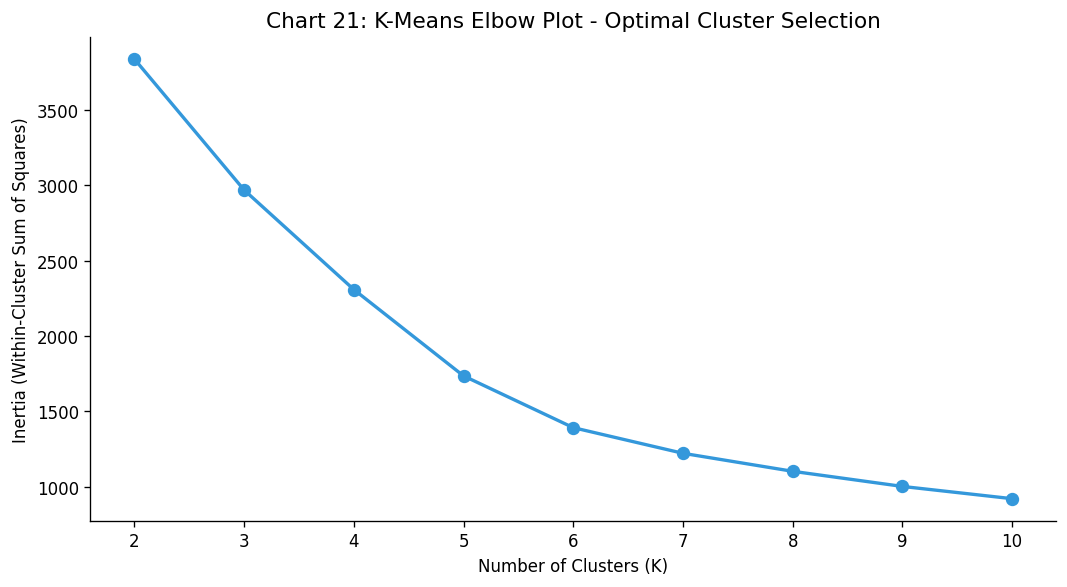

Elbow plot inertia values:
  K=2: 3837.7
  K=3: 2968.6
  K=4: 2307.9
  K=5: 1734.8
  K=6: 1391.3
  K=7: 1221.0
  K=8: 1101.6
  K=9: 1001.2
  K=10: 919.8

Select K at the point where inertia reduction slows (the elbow).


In [35]:
clustering_features = [
    'price_change_pct_24h', 'price_change_pct_30d',
    'volatility_24h_pct', 'log_market_cap',
    'momentum_score', 'volume_to_mcap_ratio'
]

X_cluster = df[clustering_features].dropna()
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, marker='o', color='#3498db', linewidth=2, markersize=7)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Chart 21: K-Means Elbow Plot - Optimal Cluster Selection', fontsize=13)
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('chart21_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print('Elbow plot inertia values:')
for k, inertia in zip(k_range, inertias):
    print(f'  K={k}: {inertia:.1f}')
print('\nSelect K at the point where inertia reduction slows (the elbow).')

In [36]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

X_cluster_df = X_cluster.copy()
X_cluster_df['cluster'] = cluster_labels

cluster_profile = X_cluster_df.groupby('cluster')[clustering_features].mean().round(3)

print(f'K-Means completed with K={OPTIMAL_K} clusters')
print('='*55)
print('Cluster Profiles (mean values):')
print(cluster_profile.to_string())
print()
print('Cluster sizes:')
print(X_cluster_df['cluster'].value_counts().sort_index().to_string())

K-Means completed with K=4 clusters
Cluster Profiles (mean values):
         price_change_pct_24h  price_change_pct_30d  volatility_24h_pct  log_market_cap  momentum_score  volume_to_mcap_ratio
cluster                                                                                                                      
0                      -5.354                23.544              10.675          17.413          11.985                 0.320
1                       5.596                54.210              16.029          17.699          34.764                 0.173
2                      -0.645                18.941               3.375          18.304          11.106                 0.047
3                      -9.851            609529.680              22.926          18.677      365713.868                 0.296

Cluster sizes:
cluster
0    150
1     91
2    722
3      1


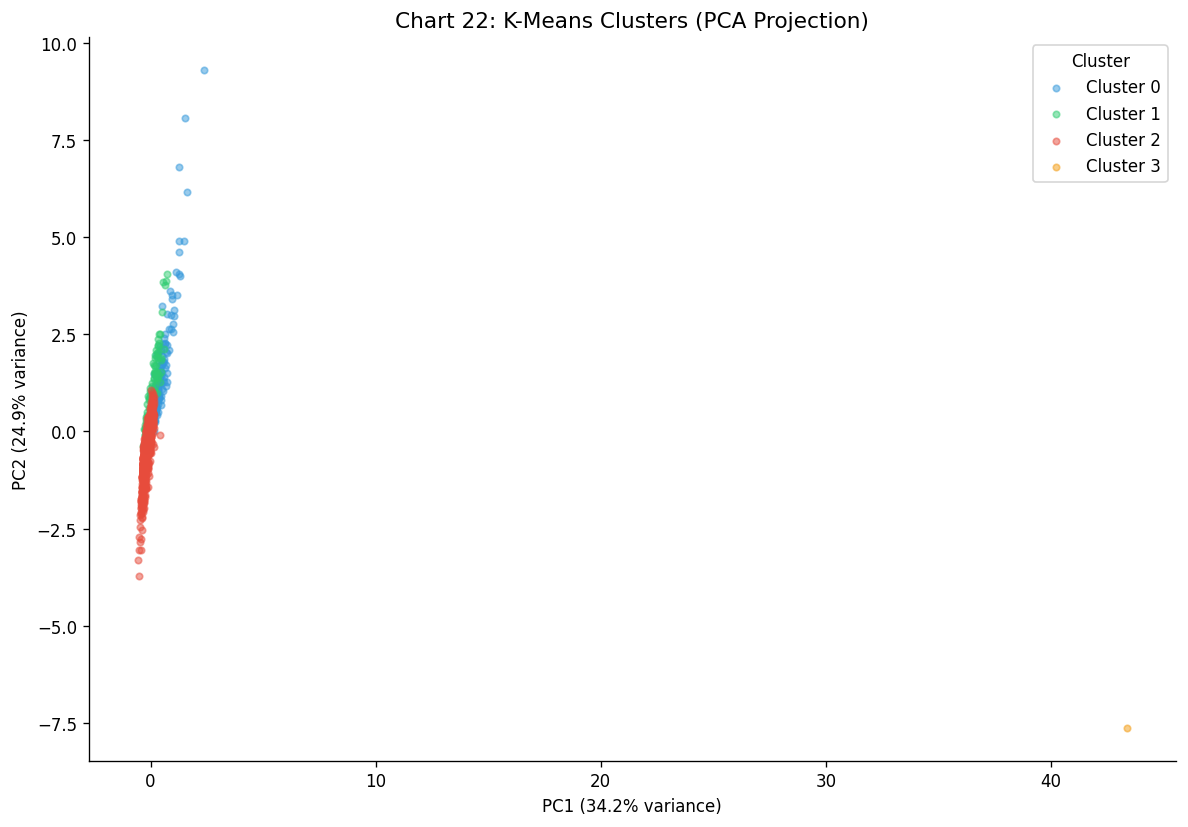

PCA explains 59.0% of total variance across 2 components.
Cluster separation in PCA space confirms that the 4 groups are meaningfully distinct.
Each cluster represents a different coin archetype (high-momentum, stable large-cap, volatile small-cap, etc.)


In [37]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
cluster_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=15, alpha=0.5, color=cluster_colors[c], label=f'Cluster {c}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Chart 22: K-Means Clusters (PCA Projection)', fontsize=13)
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('chart22_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

total_var = sum(pca.explained_variance_ratio_) * 100
print(f'PCA explains {total_var:.1f}% of total variance across 2 components.')
print('Cluster separation in PCA space confirms that the 4 groups are meaningfully distinct.')
print('Each cluster represents a different coin archetype (high-momentum, stable large-cap, volatile small-cap, etc.)')

---

# Section 4: Final Summary

In [38]:
all_acc = [lr_acc, rf_acc, xgb_acc]
all_auc = [lr_auc, rf_auc, xgb_auc]
all_names = ['Logistic Regression', 'Random Forest', 'XGBoost']

best_acc_idx = all_acc.index(max(all_acc))
best_auc_idx = all_auc.index(max(all_auc))

print('=' * 55)
print('CRYPTOSCOPE - SECTION 2 COMPLETE')
print('=' * 55)
print(f'\nDataset')
print(f'  Coins analyzed       : {len(df)}')
print(f'  Features used        : {len(feature_cols)}')
print(f'  Charts created       : 22')
print(f'\nCleaning')
print(f'  Nulls fixed          : Yes')
print(f'  Outliers treated     : Yes (3x IQR clipping)')
print(f'  New features         : 10 engineered columns')
print(f'\nModel Results')
print(f'  Logistic Regression  : Acc={lr_acc*100:.2f}%  AUC={lr_auc:.4f}  CV={lr_cv.mean()*100:.2f}%')
print(f'  Random Forest        : Acc={rf_acc*100:.2f}%  AUC={rf_auc:.4f}  CV={rf_cv.mean()*100:.2f}%')
if XGBOOST_AVAILABLE:
    print(f'  XGBoost              : Acc={xgb_acc*100:.2f}%  AUC={xgb_auc:.4f}  CV={xgb_cv.mean()*100:.2f}%')
print(f'\n  Best by Accuracy     : {all_names[best_acc_idx]} ({all_acc[best_acc_idx]*100:.2f}%)')
print(f'  Best by AUC          : {all_names[best_auc_idx]} ({all_auc[best_auc_idx]:.4f})')
print(f'\nClustering')
print(f'  K-Means clusters     : {OPTIMAL_K} (selected via elbow method)')
print(f'  PCA variance covered : {total_var:.1f}% (2 components)')
print(f'\nFiles saved')
print(f'  cryptoscope_cleaned.csv')
print('=' * 55)

CRYPTOSCOPE - SECTION 2 COMPLETE

Dataset
  Coins analyzed       : 1000
  Features used        : 15
  Charts created       : 22

Cleaning
  Nulls fixed          : Yes
  Outliers treated     : Yes (3x IQR clipping)
  New features         : 10 engineered columns

Model Results
  Logistic Regression  : Acc=69.95%  AUC=0.6967  CV=59.19%
  Random Forest        : Acc=68.91%  AUC=0.7164  CV=67.81%
  XGBoost              : Acc=69.43%  AUC=0.6895  CV=66.87%

  Best by Accuracy     : Logistic Regression (69.95%)
  Best by AUC          : Random Forest (0.7164)

Clustering
  K-Means clusters     : 4 (selected via elbow method)
  PCA variance covered : 59.0% (2 components)

Files saved
  cryptoscope_cleaned.csv
